In [1]:
#%reload_ext autoreload
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm
import h5py

import holodeck as holo
from holodeck import sams, host_relations, hardening
from holodeck import utils, plot, cosmo
from holodeck.constants import MSOL, YR, MPC, NWTG, SPLC, GYR
from holodeck.discrete.evolution import Evolution
from Nanograv_15_year_constraints import  Single_Par_Variation_GW, interpolate_lumdistmax_Nano_15, interpolate_h_ss_max_Nano_15, Detectable_Sources_Lumdist, Detectable_Strain, get_UL_vs_freq
from Nanograv_15_year_constraints import get_ss_GW_strain, get_bg_GW_strain, dl_from_strain
from astropy import coordinates
holo.log.setLevel(holo.log.ERROR)

In [3]:
sam = sams.Semi_Analytic_Model(shape=10)

In [4]:
nints=10
rangespsi0 = np.arange(-3.5,-1.3,- (-3.5+1.3)/nints)
rangeslogm0 = np.arange(+10.5, 12.7, (12.7-10.5)/nints)
rangesmu = np.arange(7.5,9.7, (9.7-7.5)/nints)
rangeseps = np.arange(0, 1, 1/nints)
rangestau = np.arange(0.1, 11.0, (11-0.1)/nints)
rangesgamma = np.arange(-1.5,0, 1.5/nints)

usedrange = rangesgamma
usedpar = '$\\gamma$'

In [5]:
#Generate frequency bins according to simulation
OBS_DUR = 10.0 * YR    # duration of PTA observations in [sec], which determines the Fourier frequency basis
NUM_FREQS = 40  # number of frequency bins
fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
NUM_REALS = 100 # Number of 'realizations' to generate
NUM_LOUDEST = 5  # Number of 'loudest' binaries to generate in each frequency bin
print(f"Number of frequency bins: {fobs.size}")
print(f"  between [{fobs[0]*YR:.2f}, {fobs[-1]*YR:.2f}] 1/yr")
print(f"          [{fobs[0]*1e9:.2f}, {fobs[-1]*1e9:.2f}] nHz")

Number of frequency bins: 40
  between [0.10, 4.00] 1/yr
          [3.17, 126.75] nHz


In [ ]:
%%time
hc_ss, hc_bg, par_ss, par_bg = Single_Par_Variation_GW(fobs_edges, usedrange, func='hardening', par='gamma_inner', NUM_REALS=NUM_REALS,NUM_LOUDEST=NUM_LOUDEST)
#changing the shape dramatically decreases computation time

14:27:43 ERROR : Warning, significant change in number-mass!  mass: 8.39e-01 ==> 1.86e+00 || change = 1.2232e+00 [sam.py:static_binary_density]


In [9]:
Chirp_Mass_ss_parvar = []
Lumdist_parvar = []
for i in np.arange(nints):
    Chirp_Mass_ss_parvar.append(utils.chirp_mass_mtmr(par_ss[i][0],par_ss[i][1])) #Chirp Mass in grams
    Lumdist_parvar.append(cosmo.luminosity_distance(par_ss[i][3]).cgs.value/MPC)
Chirp_Mass_ss_parvar = np.array(Chirp_Mass_ss_parvar)
Lumdist_parvar = np.array(Lumdist_parvar)

In [10]:
fobsarr_var = []
Upper_boundsL_R_eff = []
Upper_boundsL_All_Sky = []
for i in range(nints):
    Upper_boundsL_R_eff.append(interpolate_lumdistmax_Nano_15(fobs,par_ss[i][3],Chirp_Mass_ss_parvar[i],model='r_eff'))
    Upper_boundsL_All_Sky.append(interpolate_lumdistmax_Nano_15(fobs,par_ss[i][3],Chirp_Mass_ss_parvar[i],model='all_sky'))
    fobsarr_var.append(np.tensordot(fobs,np.ones(NUM_REALS),axes=0))
fobsarr_var = np.array(fobsarr_var)
Upper_boundsL_R_eff = np.array(Upper_boundsL_R_eff)
Upper_boundsL_All_Sky = np.array(Upper_boundsL_All_Sky)

In [11]:
##Calculates the total distance between the
dist_R_eff = np.sum(np.log10(Lumdist_parvar) - np.log10(Upper_boundsL_R_eff),axis=(2,3))
dist_A = np.sum(np.log10(Lumdist_parvar) - np.log10(Upper_boundsL_All_Sky),axis=(2,3))
distavgpfreq_R_eff = dist_R_eff/(NUM_LOUDEST*NUM_REALS)
distavgfreq_A = dist_A/(NUM_LOUDEST*NUM_REALS)

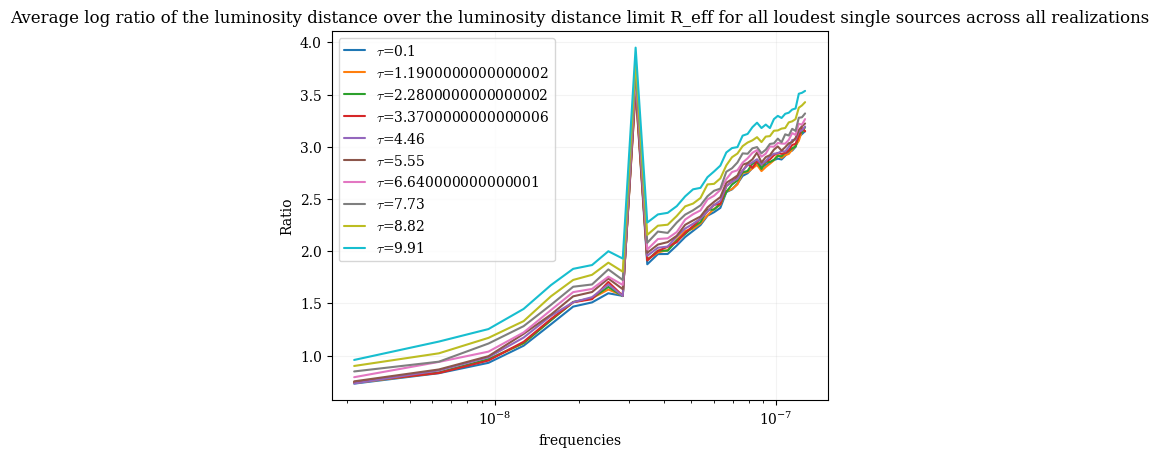

In [12]:
for i,v in enumerate(distavgpfreq_R_eff):
    plt.plot(fobs,v,label=f'{usedpar}={usedrange[i]}')
plt.xlabel('frequencies')
plt.ylabel('Ratio')
plt.title(f'Average log ratio of the luminosity distance over the luminosity distance limit R_eff for all loudest single sources across all realizations')
plt.xscale('log')
plt.legend()

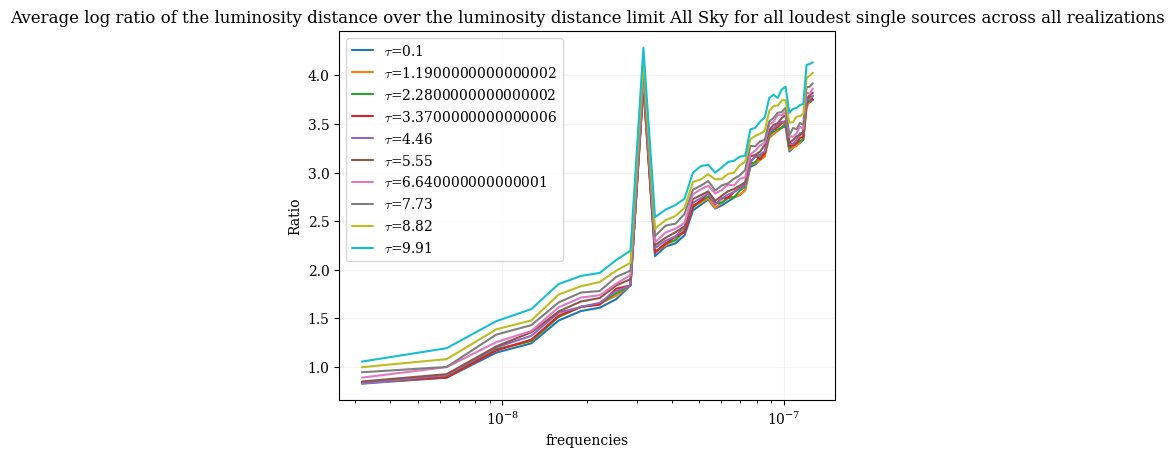

In [13]:
for i,v in enumerate(distavgfreq_A):
    plt.plot(fobs,v,label=f'{usedpar}={usedrange[i]}')
plt.xlabel('frequencies')
plt.ylabel('Ratio')
plt.title(f'Average log ratio of the luminosity distance over the luminosity distance limit All Sky for all loudest single sources across all realizations')
plt.xscale('log')
plt.legend()

In [14]:
distavg_R_eff = []
distavg_A = []
for i in range(nints):
    distavg_R_eff.append(sum(distavgpfreq_R_eff[i])/NUM_FREQS)
    distavg_A.append(sum(distavgfreq_A[i])/NUM_FREQS)
print(distavg_R_eff) #Average ratio over all frequencies for R_eff
print(distavg_A) #Average ratio over all frequencies for All Sky

[2.3359820275612306, 2.3490240055979177, 2.3629817280113277, 2.3749308628749244, 2.392545133175877, 2.422426400279076, 2.468196693878141, 2.5173513655742203, 2.602687799761283, 2.710730805699078]
[2.6684455767154285, 2.681487554752116, 2.6954452771655237, 2.7073944120291227, 2.7250086823300737, 2.7548899494332733, 2.800660243032338, 2.849814914728417, 2.93515134891548, 3.0431943548532745]


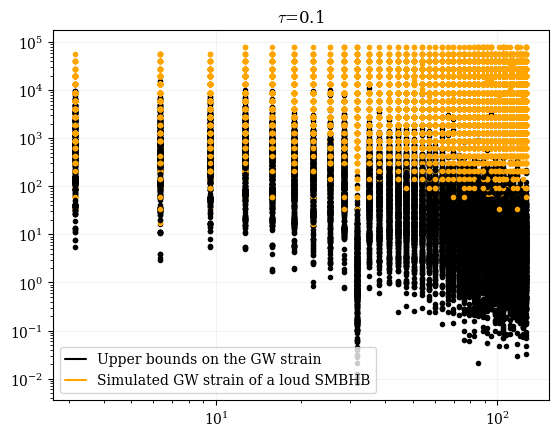

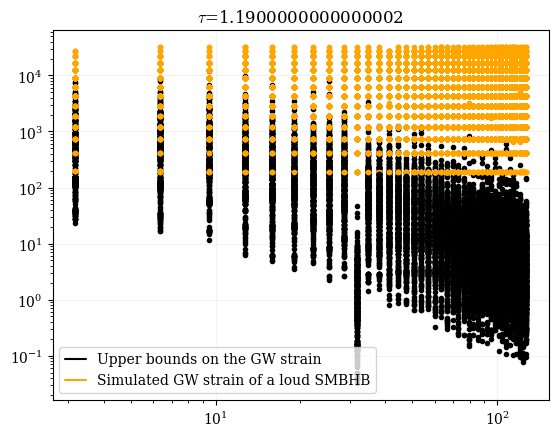

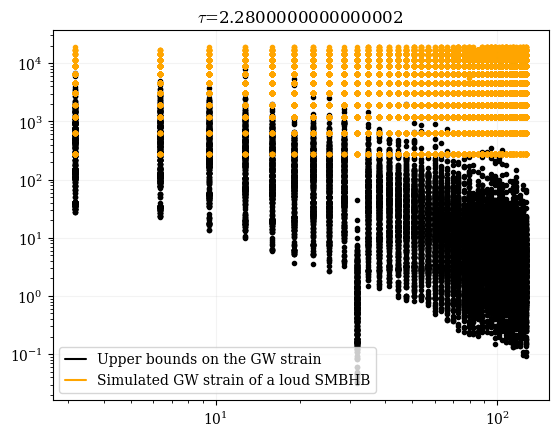

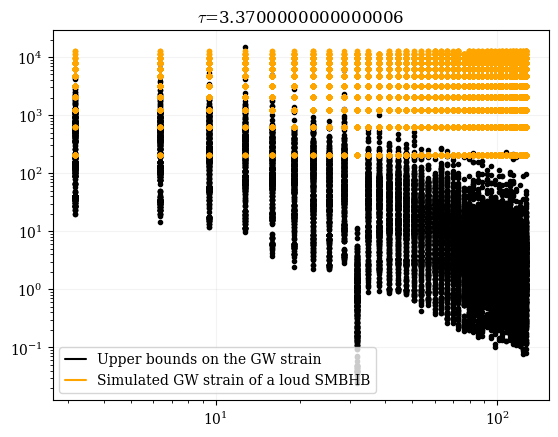

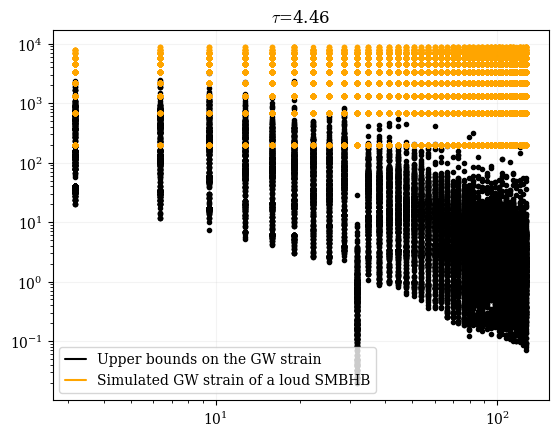

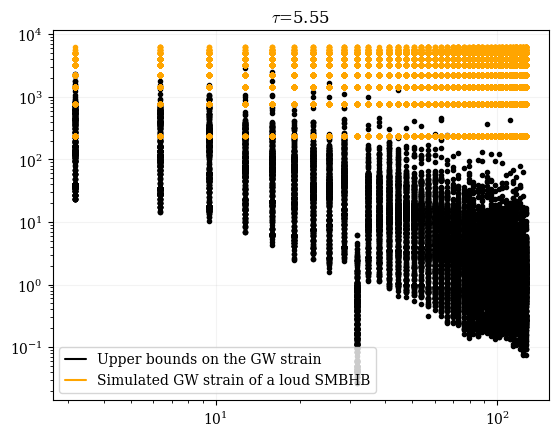

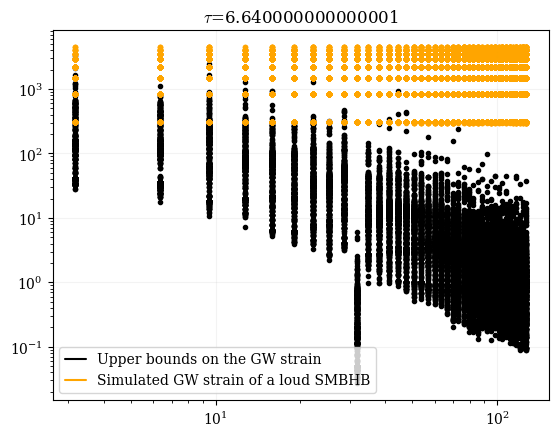

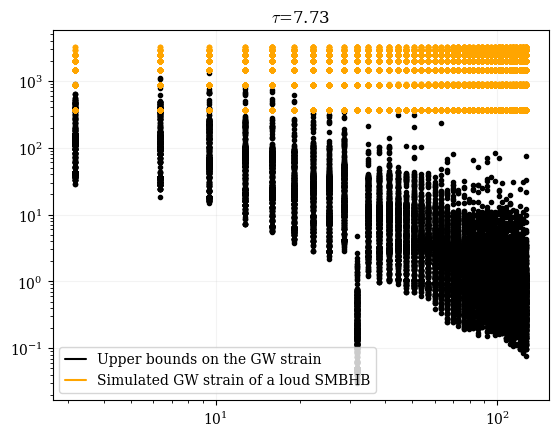

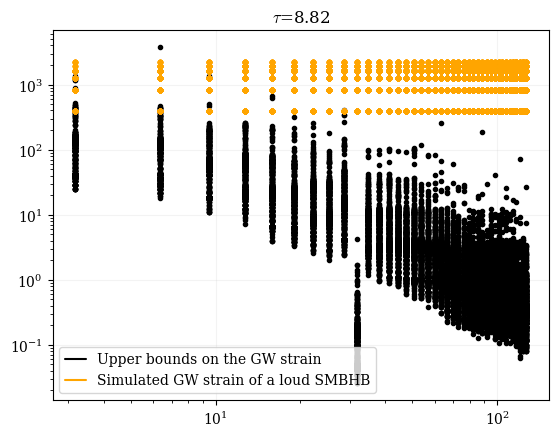

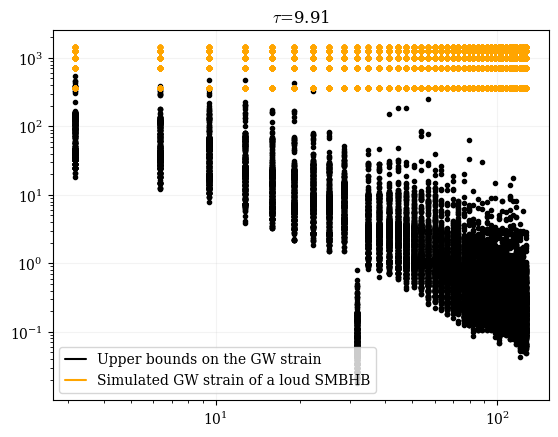

In [15]:
for i in range(nints):
    plt.figure()
    plt.title(f'{usedpar}={usedrange[i]}')
    plt.loglog([],[],color='black',label='Upper bounds on the GW strain')
    plt.loglog([],[],color='orange',label='Simulated GW strain of a loud SMBHB')
    plt.legend()
    for j in range(NUM_LOUDEST):
        plt.loglog(fobsarr_var[i]*10**9,Upper_boundsL_R_eff[i,:,:,j],'.',color='black')
        plt.loglog(fobsarr_var[i]*10**9,Lumdist_parvar[i,:,:,j],'.',color='orange')
#plot distribution of ratios between simulated and max lumdist

In [20]:
FilteredLumdist_R_eff_var = []
FilteredLumdist_A_var = []
FilteredFreqs_R_eff_var = []
FilteredFreqs_A_var = [] 
corresponding_upper_limit_R_eff_var = [] 
corresponding_upper_limit_A_var = []
realization_number_R_eff_var = []
realization_number_A_var = []
frequency_of_SMBHB_R_eff_var = []
frequency_of_SMBHB_A_var = []
for i in range(nints):
    saves1 = Detectable_Sources_Lumdist(fobs,Lumdist_parvar[i],Upper_boundsL_R_eff[i])
    saves2 = Detectable_Sources_Lumdist(fobs,Lumdist_parvar[i],Upper_boundsL_All_Sky[i])
    FilteredLumdist_R_eff_var.append(saves1[0]) 
    FilteredLumdist_A_var.append(saves2[0]) 
    FilteredFreqs_R_eff_var.append(saves1[1])
    FilteredFreqs_A_var.append(saves2[1])
    corresponding_upper_limit_R_eff_var.append(saves1[2])
    corresponding_upper_limit_A_var.append(saves2[2])
    realization_number_R_eff_var.append(saves1[3])
    realization_number_A_var.append(saves2[3])
    frequency_of_SMBHB_R_eff_var.append(saves1[4]) 
    frequency_of_SMBHB_A_var.append(saves2[4])
    
FilteredLumdist_R_eff_var = np.array(FilteredLumdist_R_eff_var)
FilteredLumdist_A_var = np.array(FilteredLumdist_A_var)
FilteredFreqs_R_eff_var = np.array(FilteredFreqs_R_eff_var)
FilteredFreqs_A_var = np.array(FilteredFreqs_A_var)
corresponding_upper_limit_R_eff_var = np.array(corresponding_upper_limit_R_eff_var)
corresponding_upper_limit_A_var = np.array(corresponding_upper_limit_A_var)

In [21]:
c1_var = []
b1_var = []
for i in range(nints):
    saves3 = np.histogram(realization_number_R_eff_var[i],bins=NUM_REALS)
    c1_var.append(saves3[0])
    b1_var.append(saves3[1])
success1_var = list(np.zeros(nints))
total1_var = []
for i in range(nints):
    total1_var.append(len(c1_var[i]))
    for j in c1_var[i]:
        if j != 0:
            success1_var[i] += 1
c2_var = []
b2_var = []
for i in range(nints):
    saves4 = np.histogram(frequency_of_SMBHB_R_eff_var[i],bins=NUM_REALS)
    c2_var.append(saves4[0])
    b2_var.append(saves4[1])
success2_var = list(np.zeros(nints))
total2_var = []
for i in range(nints):
    total2_var.append(len(c2_var[i]))
    for j in c2_var[i]:
        if j != 0:
            success2_var[i] += 1

In [22]:
c3_var = []
b3_var = []
for i in range(nints):
    saves5 = np.histogram(realization_number_A_var[i],bins=NUM_REALS)
    c3_var.append(saves5[0])
    b3_var.append(saves5[1])
success3_var = list(np.zeros(nints))
total3_var = []
for i in range(nints):
    total3_var.append(len(c3_var[i]))
    for j in c3_var[i]:
        if j != 0:
            success3_var[i] += 1
c4_var = []
b4_var = []
for i in range(nints):
    saves6 = np.histogram(frequency_of_SMBHB_A_var[i],bins=NUM_REALS)
    c4_var.append(saves4[0])
    b4_var.append(saves4[1])
success4_var = list(np.zeros(nints))
total4_var = []
for i in range(nints):
    total4_var.append(len(c4_var[i]))
    for j in c4_var[i]:
        if j != 0:
            success4_var[i] += 1

There is a 5.0% chance to detect a single source, with a mean number of detections of 0.06 when $\tau$ = 0.1.
The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is 2.3359820275612306
There is a 6.0% chance to detect a single source, with a mean number of detections of 0.07 when $\tau$ = 1.1900000000000002.
The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is 2.3490240055979177
There is a 8.0% chance to detect a single source, with a mean number of detections of 0.08 when $\tau$ = 2.2800000000000002.
The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is 2.3629817280113277
There is a 6.0% chance to detect a single source, with a mean number of detections of 0.06 when $\tau$ = 3.3700000000000006.
The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is 2.

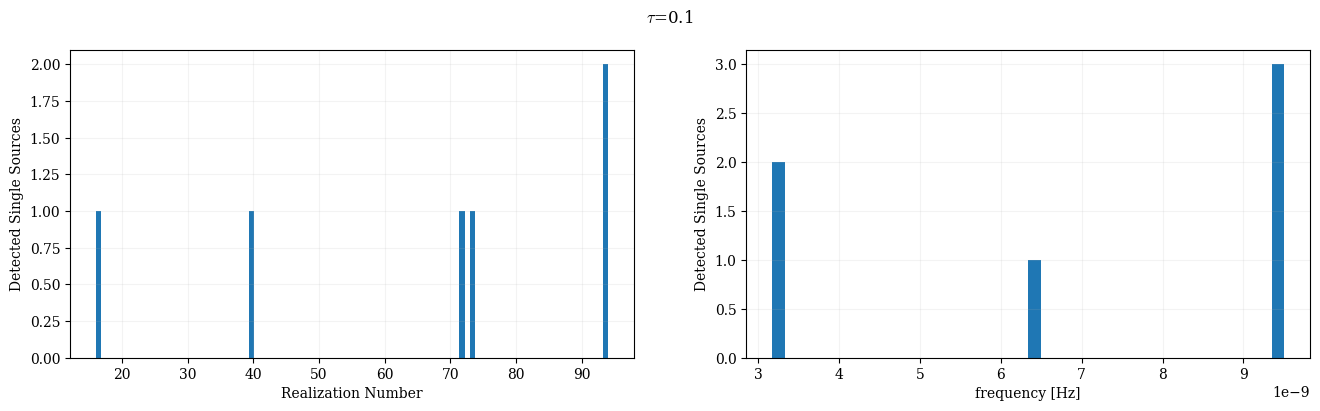

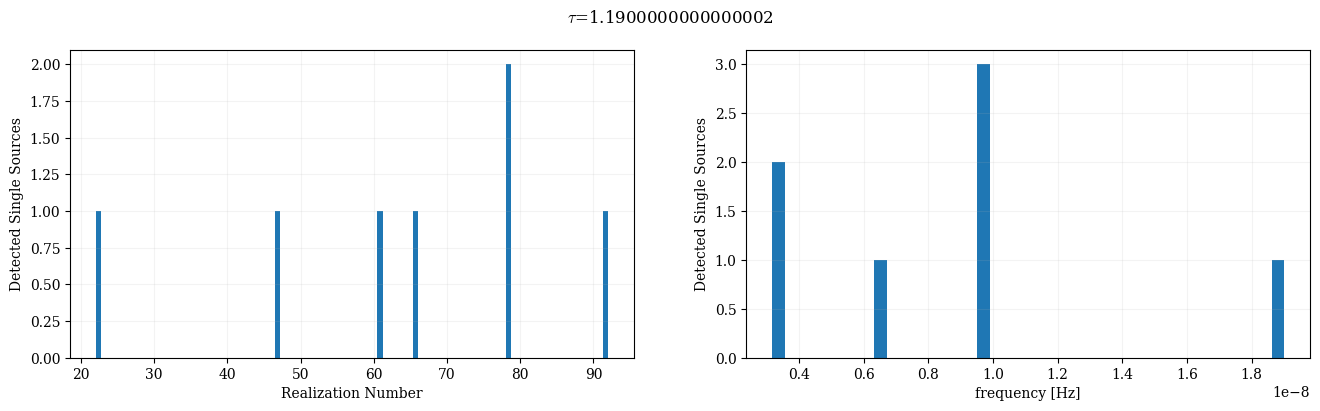

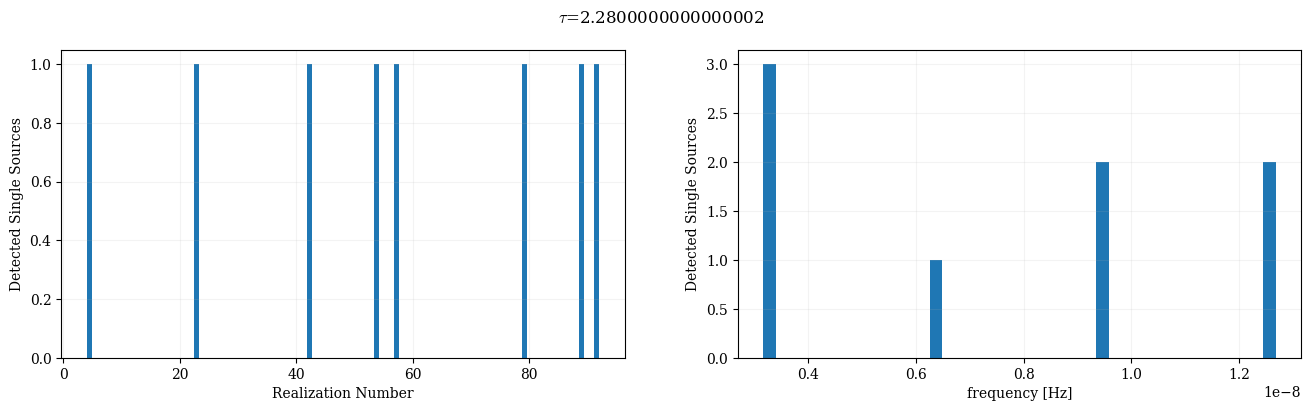

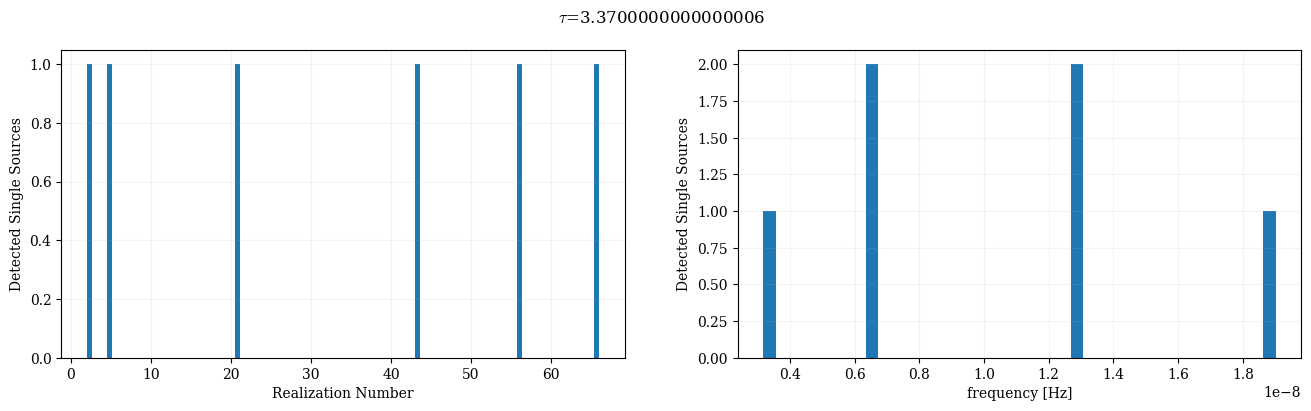

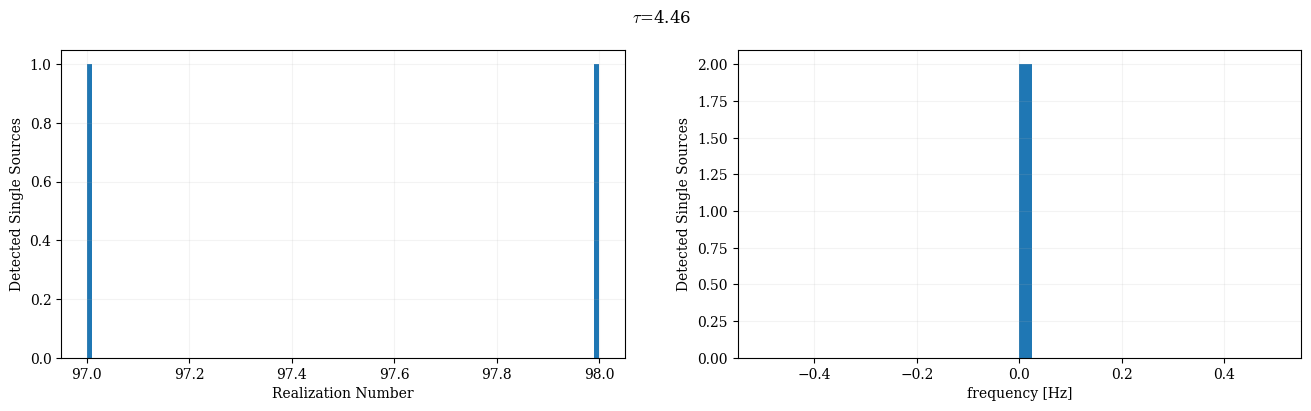

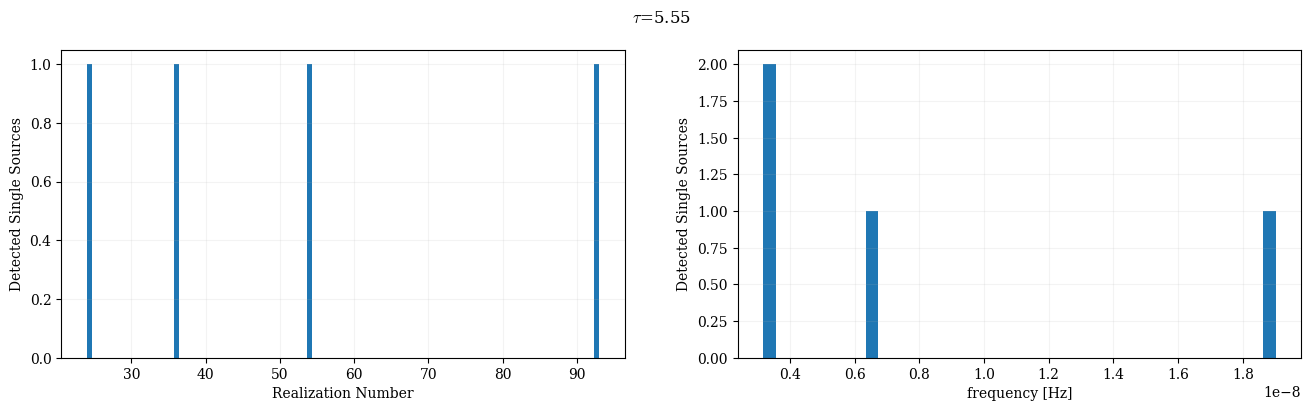

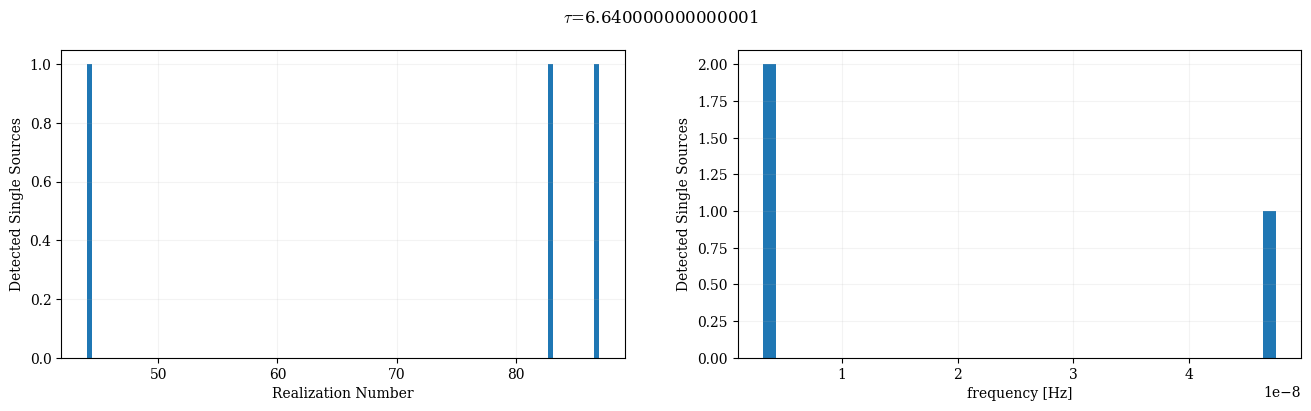

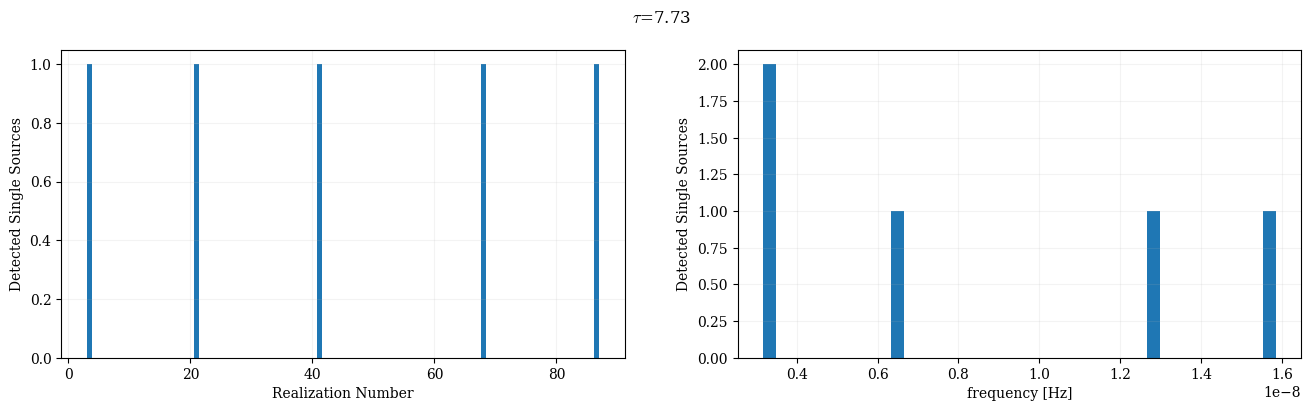

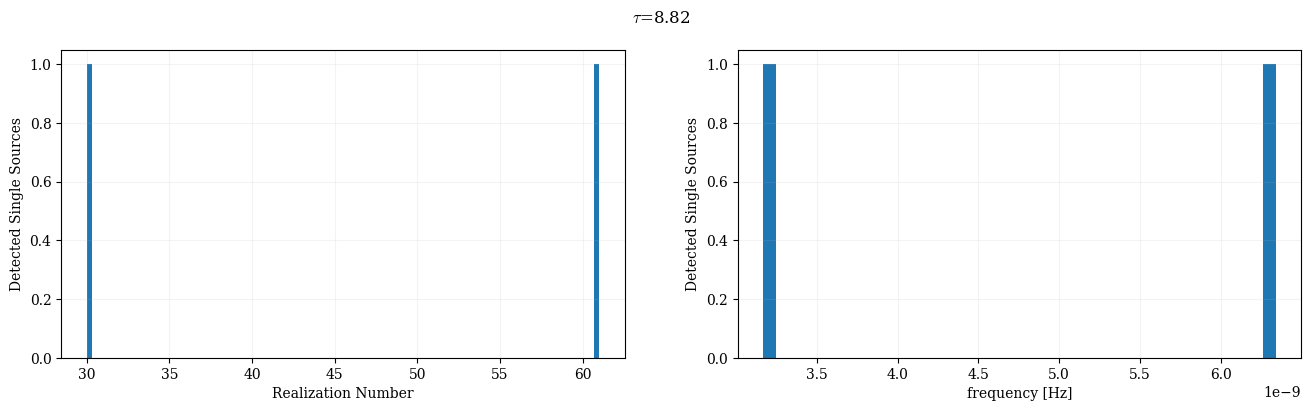

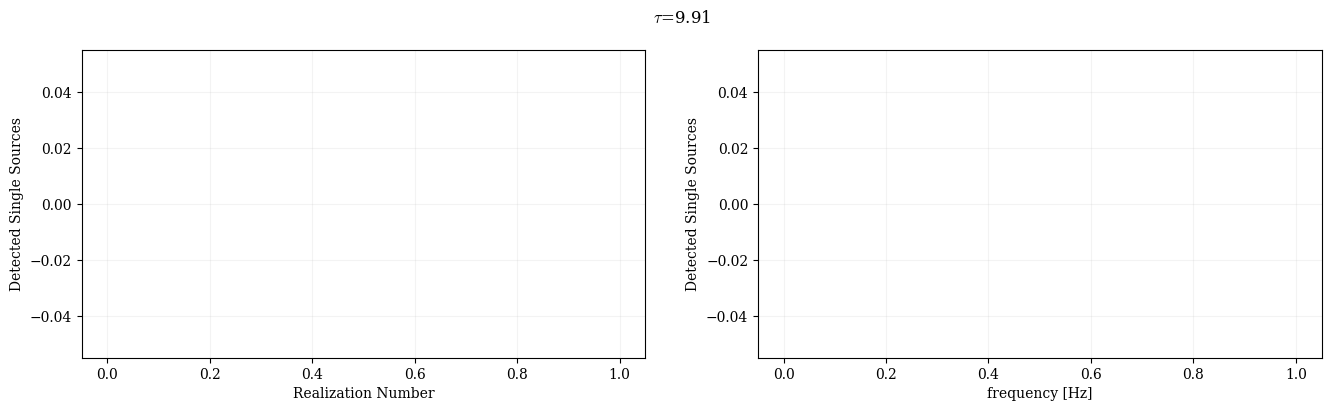

In [23]:
L_R_eff = []
for i in range(nints):
    fig, axs = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle(f'{usedpar}={usedrange[i]}')
    axs[0].hist(realization_number_R_eff_var[i],bins=NUM_REALS)
    axs[0].set_xlabel('Realization Number')
    axs[0].set_ylabel('Detected Single Sources')
    axs[1].hist(frequency_of_SMBHB_R_eff_var[i],bins=NUM_FREQS)
    axs[1].set_xlabel('frequency [Hz]')
    axs[1].set_ylabel('Detected Single Sources')
    L_R_eff.append(1 - success1_var[i]/total1_var[i])
    print(f'There is a {100*success1_var[i]/total1_var[i]}% chance to detect a single source, with a mean number of detections of {np.mean(c1_var[i])} when {usedpar} = {usedrange[i]}.')
    print(f'The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is {distavg_R_eff[i]}')

There is a 2.0% chance to detect a single source, with a mean number of detections of 0.02 when $\tau$ = 0.1.
The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is 2.6684455767154285
There is a 5.0% chance to detect a single source, with a mean number of detections of 0.06 when $\tau$ = 1.1900000000000002.
The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is 2.681487554752116
There is a 4.0% chance to detect a single source, with a mean number of detections of 0.04 when $\tau$ = 2.2800000000000002.
The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is 2.6954452771655237
There is a 4.0% chance to detect a single source, with a mean number of detections of 0.04 when $\tau$ = 3.3700000000000006.
The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is 2.7

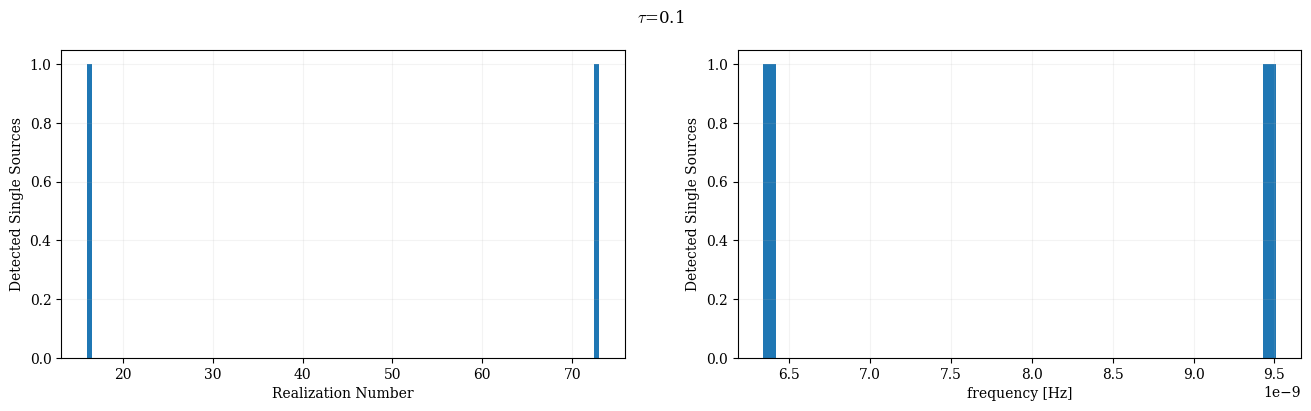

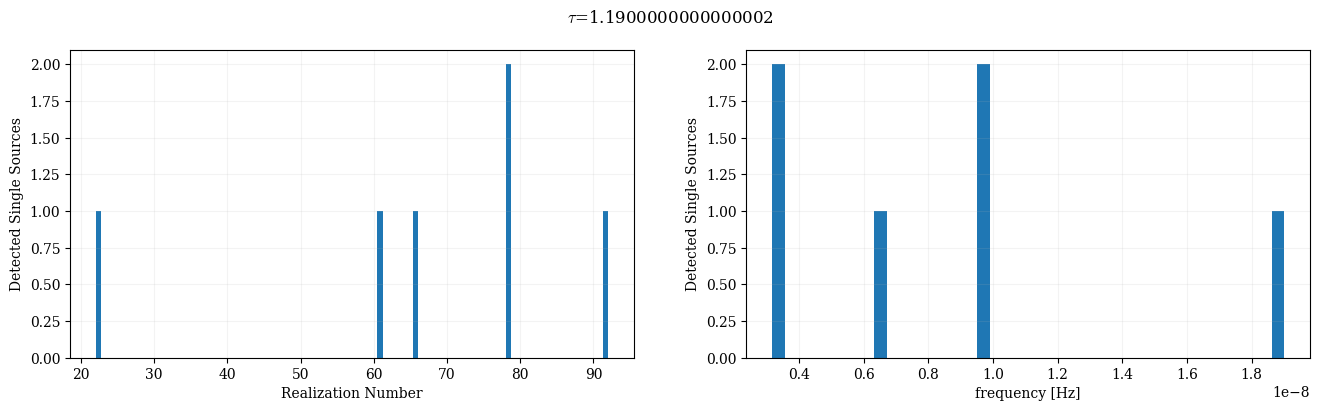

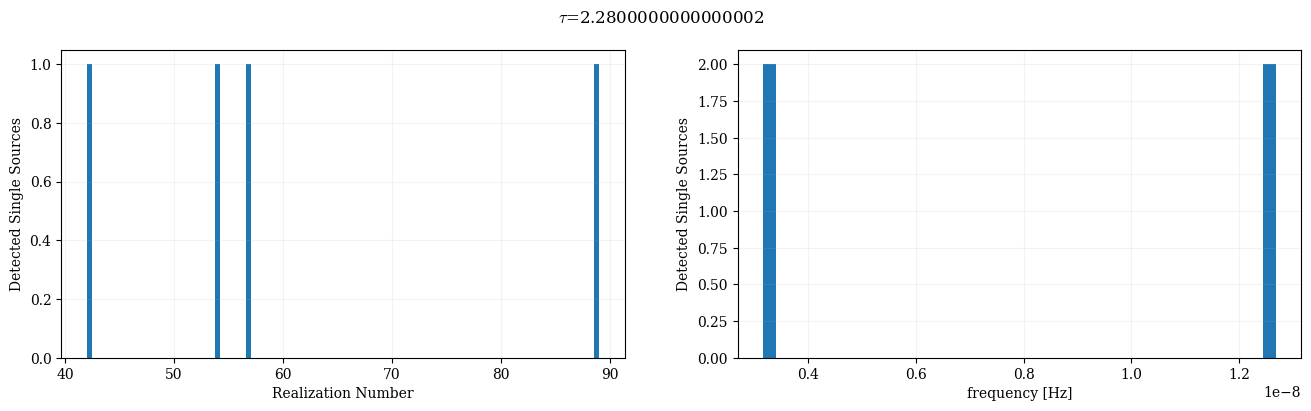

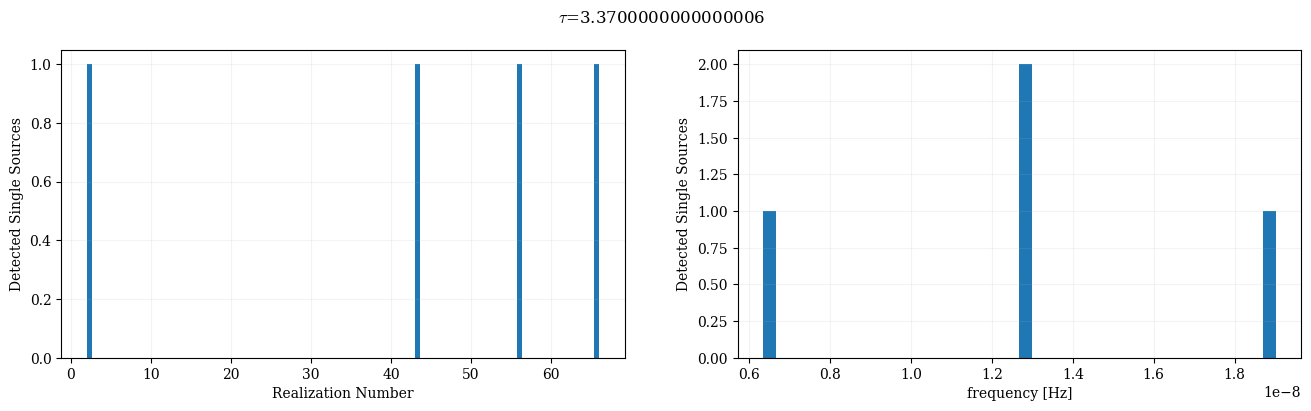

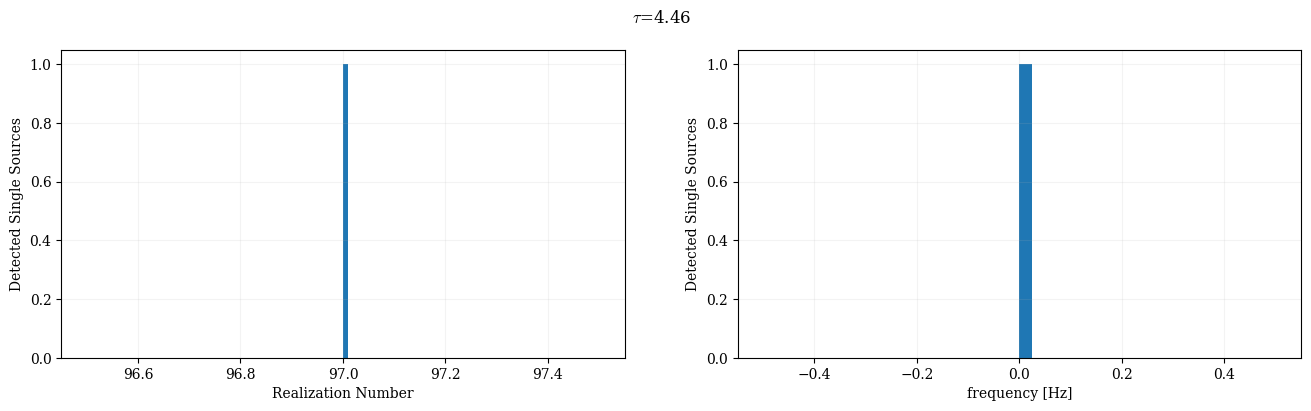

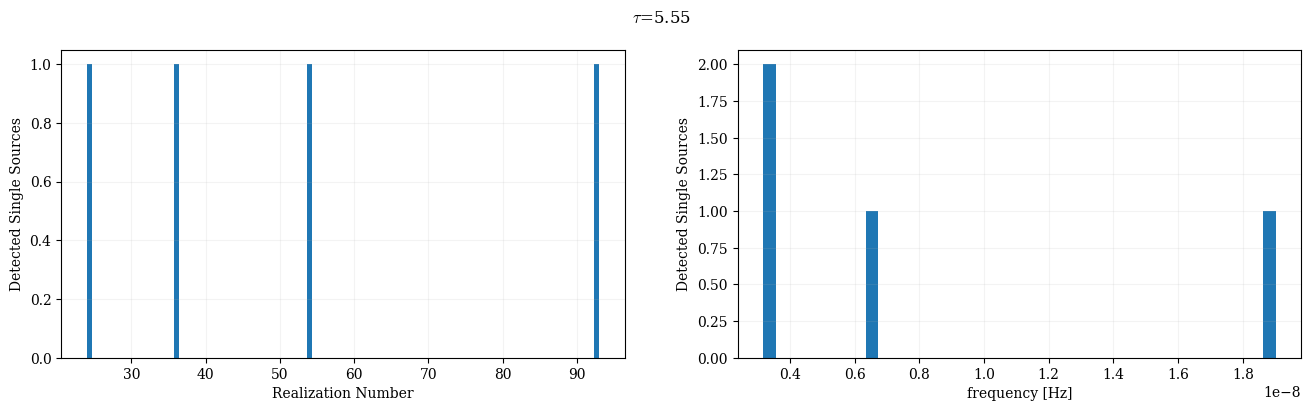

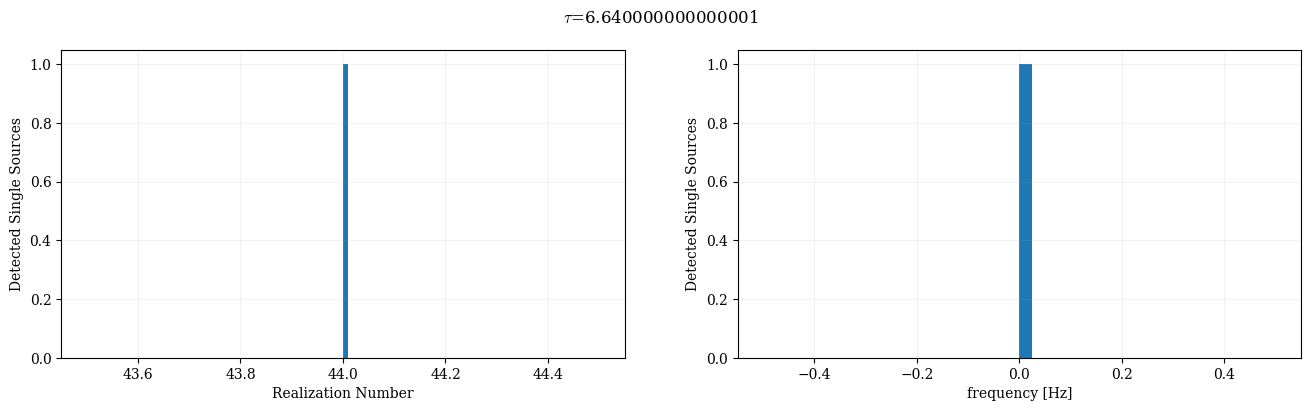

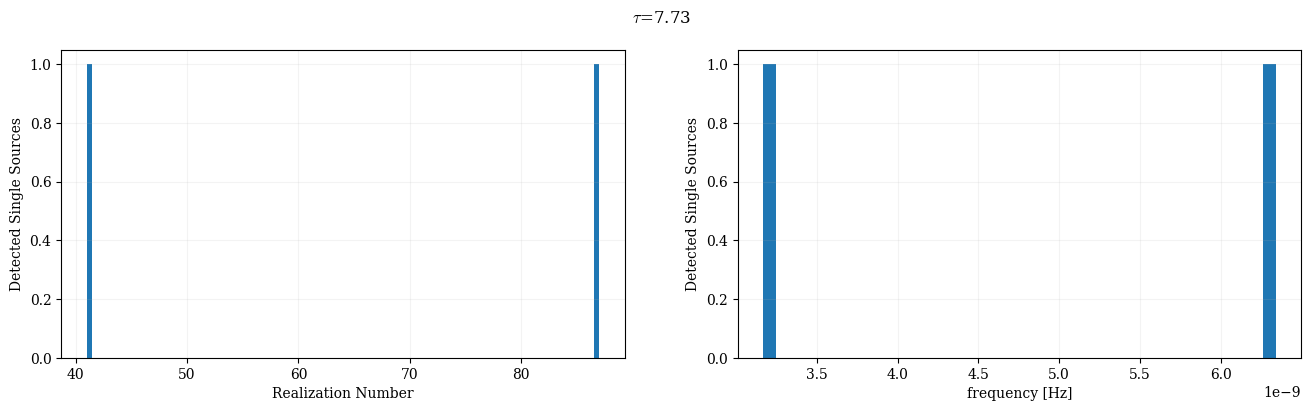

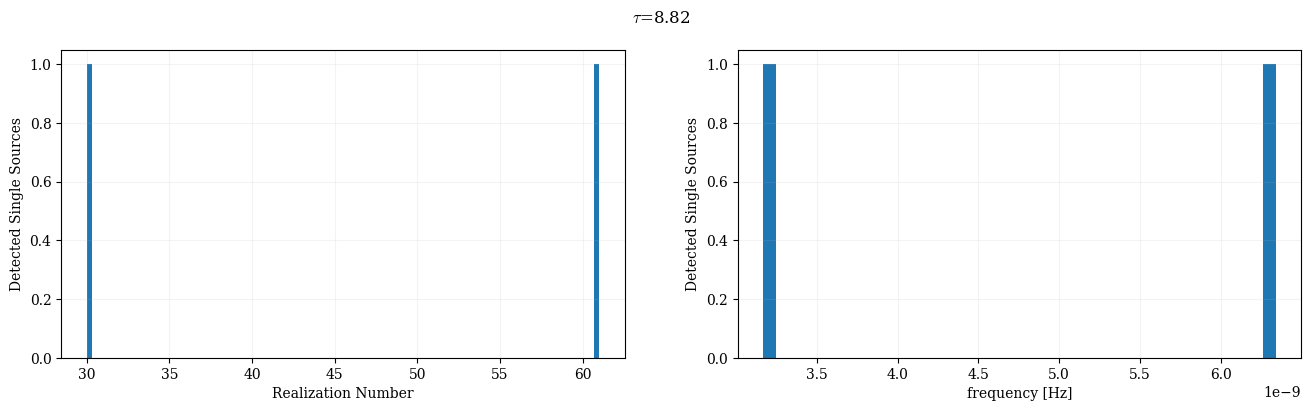

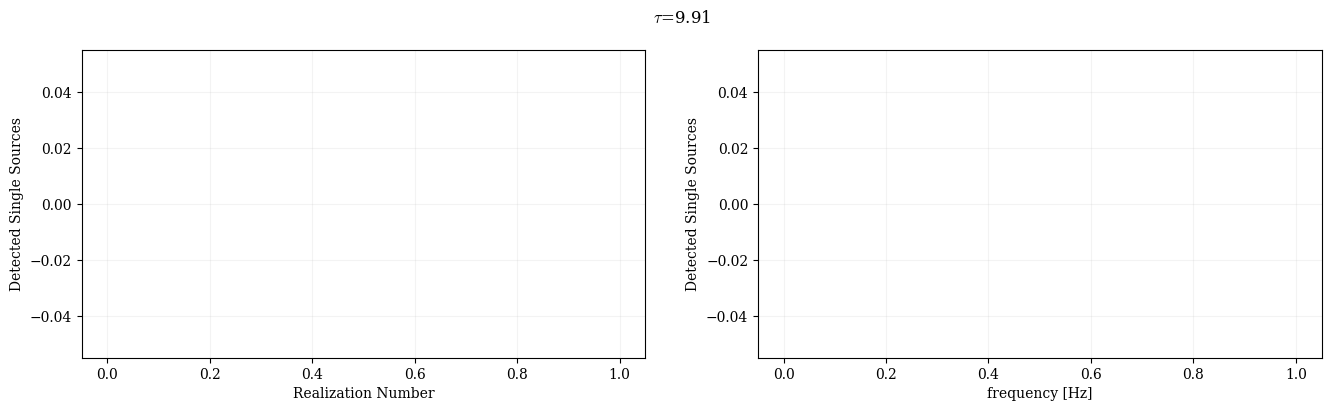

In [24]:
L_A = []
for i in range(nints):
    fig, axs = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle(f'{usedpar}={usedrange[i]}')
    axs[0].hist(realization_number_A_var[i],bins=NUM_REALS)
    axs[0].set_xlabel('Realization Number')
    axs[0].set_ylabel('Detected Single Sources')
    axs[1].hist(frequency_of_SMBHB_A_var[i],bins=NUM_FREQS)
    axs[1].set_xlabel('frequency [Hz]')
    axs[1].set_ylabel('Detected Single Sources')
    L_A.append(1 - success3_var[i]/total3_var[i])
    print(f'There is a {100*success3_var[i]/total3_var[i]}% chance to detect a single source, with a mean number of detections of {np.mean(c3_var[i])} when {usedpar} = {usedrange[i]}.')
    print(f'The total average log distance^2 between the distance limit and the detected luminosity for undetected sources is {distavg_A[i]}')

Text(0.5, 1.0, 'Likelihood plot for L_max = L_All_Sky')

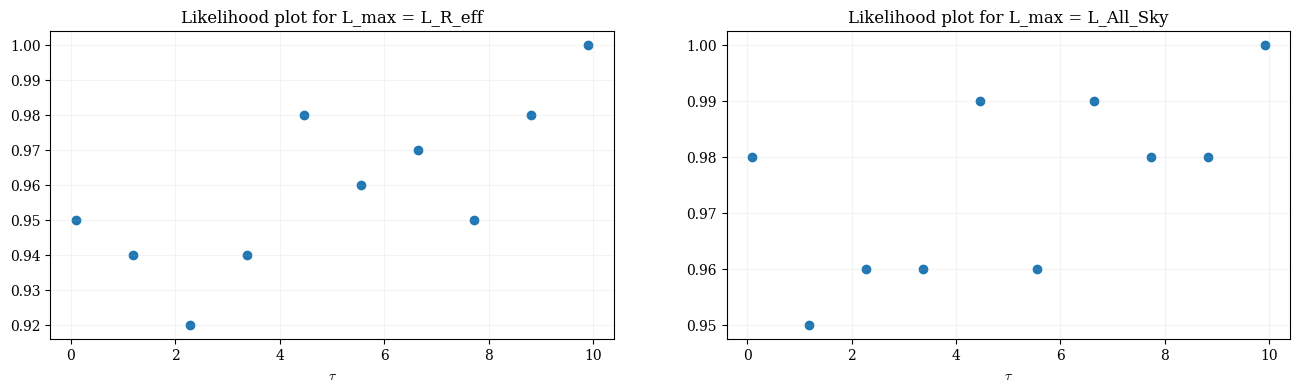

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
axs[0].scatter(usedrange,L_R_eff)
axs[0].set_xlabel(usedpar)
axs[0].set_title('Likelihood plot for L_max = L_R_eff')
axs[1].scatter(usedrange,L_A)
axs[1].set_xlabel(usedpar)
axs[1].set_title('Likelihood plot for L_max = L_All_Sky')
#plt.savefig(f'Figures/Likelihood of ')

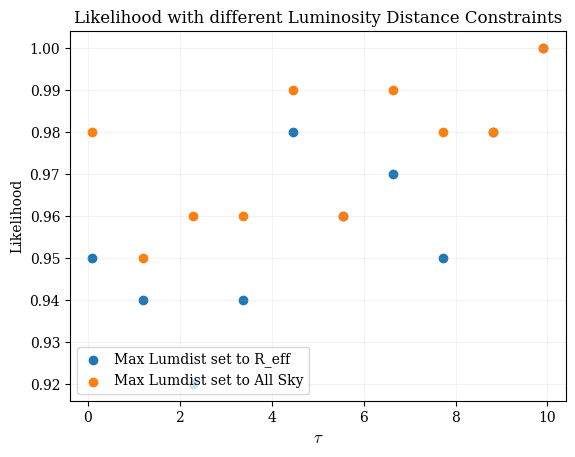

In [27]:
plt.title('Likelihood with different Luminosity Distance Constraints')
plt.xlabel(usedpar,fontsize=12)
plt.ylabel('Likelihood')
plt.scatter(usedrange,L_R_eff,label='Max Lumdist set to R_eff')
plt.scatter(usedrange,L_A,label='Max Lumdist set to All Sky')
plt.legend(loc='lower left',fontsize=10)
plt.savefig(f'Figures/Likelihoods')